### Bloco Markdown 1: O Ecossistema de Dados e Bibliotecas

# 1. Bibliotecas de Análise de Dados
Em Python, não construímos soluções de dados do zero. Utilizamos **bibliotecas**, que são pacotes de código open-source com funções pré-implementadas e altamente otimizadas para tarefas complexas. 

As três bibliotecas fundamentais (a "santíssima trindade" da ciência de dados em Python) são:
* **NumPy (Numerical Python):** Base para cálculos numéricos e matriciais. Suas rotinas são escritas em C/C++, garantindo alta performance.
* **Pandas:** Focada em manipulação de dados estruturados (tabelares), simulando o comportamento de planilhas Excel ou tabelas SQL.
* **Matplotlib / Seaborn:** Bibliotecas para criação de gráficos e visualização de dados.

**Instalação e Importação:**
Em ambientes como Google Colab ou Jupyter, instalamos pacotes via comandos de shell (`!pip install`) e utilizamos os aliases universais `np`, `pd` e `plt`. No entanto, em ambientes virtuais (venv), recomenda-se o uso do magic command `%pip install`. Diferente da exclamação, o prefixo % garante que a instalação ocorra exatamente no kernel em execução no notebook, evitando conflitos com o Python do sistema.

In [1]:
### Bloco de Código 1: Setup do Ambiente

# Instalação das bibliotecas (no Colab já vêm instaladas, mas é boa prática conhecer o comando)
%pip install numpy pandas matplotlib seaborn

# Importação com os aliases convencionais
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

  Using cached numpy-2.0.2-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
  Using cached pandas-2.3.3-cp39-cp39-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (91 kB)
  Using cached matplotlib-3.9.4-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (11 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached pytz-2026.1.post1-py2.py3-none-any.whl.metadata (22 kB)
  Using cached contourpy-1.3.0-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.60.2-cp39-cp39-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (113 kB)
  Using cached kiwisolver-1.4.7-cp39-cp39-manylinux_2_12_x86_64.manylinux2010_x86_64.whl.metadata (6.3 kB)
  Using cached pillow-11.3.0-cp39-cp39-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)

### Bloco Markdown 2: Computação Vetorial com NumPy

# 2. Matrizes e Computação Vetorial (NumPy)
O elemento central do NumPy é o `Array` (ou `ndarray`). Diferente das listas nativas do Python (que são unidimensionais e não suportam operações matemáticas diretas), os *arrays* podem ter múltiplas dimensões (matrizes, tensores) e são otimizados matematicamente.

* **Broadcasting:** Ao multiplicar uma lista nativa por 2 em Python, os elementos são duplicados. Ao multiplicar um *array* NumPy por 2, ocorre o *broadcasting*: a operação matemática é aplicada individualmente a cada elemento (elemento a elemento) ou expandida ao longo das colunas/linhas.
* **Álgebra Linear:** O NumPy permite operações avançadas, como a multiplicação matricial real, que é feita através do operador `@` ou do método `.dot()`.
* **Aleatoriedade e Sementes (Seed):** Geração de números pseudoaleatórios é essencial para simulações e pesos iniciais em redes neurais. Utiliza-se `np.random.seed(42)` para travar a semente e garantir a reprodutibilidade dos experimentos.

In [2]:
### Bloco de Código 2: NumPy na Prática

# Lista vs Array
lista_nativa = [1, 2, 3]
vetor_numpy = np.array([1, 2, 3])

print("Lista x 2:", lista_nativa * 2)    # Duplica os elementos
print("Array x 2:", vetor_numpy * 2)     # Broadcasting (multiplica os valores)

# Matrizes e Álgebra Linear Avançada
matriz_A = np.array([[1, 2], [3, 4]])
matriz_B = np.array([[5, 6], [7, 8]])

# Multiplicação Elemento a Elemento vs Multiplicação Matricial
print("\nMultiplicação Elemento a Elemento:\n", matriz_A * matriz_B)
print("\nMultiplicação Matricial (@ ou dot):\n", matriz_A @ matriz_B)

# Estatística Básica e Semente Aleatória
np.random.seed(42) # Garante que os números aleatórios gerados sejam os mesmos sempre
dados_normais = np.random.normal(loc=0, scale=1, size=100) # Média 0, Desvio padrão 1
print(f"\nMédia da distribuição: {np.mean(dados_normais):.4f}")
print(f"Desvio Padrão: {np.std(dados_normais):.4f}")

Lista x 2: [1, 2, 3, 1, 2, 3]
Array x 2: [2 4 6]

Multiplicação Elemento a Elemento:
 [[ 5 12]
 [21 32]]

Multiplicação Matricial (@ ou dot):
 [[19 22]
 [43 50]]

Média da distribuição: -0.1038
Desvio Padrão: 0.9036


### Bloco Markdown 3: Pandas e DataFrames

# 3. Estruturas de Dados com Pandas (DataFrames)
O objeto primário do Pandas é o **DataFrame**, uma matriz estruturada que contém linhas e colunas rotuladas. 

A análise exploratória inicial consiste em entender o formato dos dados:
* **Leitura:** `pd.read_csv()` e `pd.read_excel()` carregam dados de arquivos externos diretamente para a memória.
* **Inspeção Rápida:** `df.head(n)` e `df.tail(n)` exibem as primeiras e últimas linhas. `df.shape` retorna as dimensões (linhas, colunas).
* **Auditoria de Dados:** O método `df.info()` revela os tipos de dados alocados na memória (inteiros, floats, strings/objects) e `df.describe()` gera um sumário estatístico completo (média, quartis, min/max) excluindo variáveis categóricas.
* **Valores Nulos:** Lidar com dados faltantes (NaN) é vital. Usa-se `df.isna().sum()` para quantificar valores vazios.

In [6]:
### Bloco de Código 3: Análise Exploratória

# Criando um DataFrame a partir de um dicionário (simulando uma leitura de CSV)
dados = {
    'especie': ['Setosa', 'Versicolor', 'Virginica', 'Setosa', 'Versicolor'],
    'comprimento_cm': [5.1, 7.0, 6.3, 4.9, 6.4],
    'largura_cm': [3.5, 3.2, 3.3, 3.0, None], # Inserindo um valor nulo propositalmente
    'preco_venda': [15.0, 25.5, 30.0, 12.0, 22.0]
}
df = pd.DataFrame(dados)

# Inspeção inicial
print("Primeiras linhas:")
display(df.head(3))

print("\nResumo das Variáveis:")
display(df.info())

print("\nEstatística Descritiva:")
display(df.describe())

print("\nVerificação de Valores Nulos:")
print(df.isna().sum())

Primeiras linhas:


,especie,comprimento_cm,largura_cm,preco_venda
0,Setosa,5.1,3.5,15.0
1,Versicolor,7.0,3.2,25.5
2,Virginica,6.3,3.3,30.0



Resumo das Variáveis:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   especie         5 non-null      object 
 1   comprimento_cm  5 non-null      float64
 2   largura_cm      4 non-null      float64
 3   preco_venda     5 non-null      float64
dtypes: float64(3), object(1)
memory usage: 288.0+ bytes


None


Estatística Descritiva:


,comprimento_cm,largura_cm,preco_venda
count,5.000000,4.000000,5.000000
mean,5.940000,3.250000,20.900000
std,0.901665,0.208167,7.402702
min,4.900000,3.000000,12.000000
25%,5.100000,3.150000,15.000000
50%,6.300000,3.250000,22.000000
75%,6.400000,3.350000,25.500000
max,7.000000,3.500000,30.000000



Verificação de Valores Nulos:
especie           0
comprimento_cm    0
largura_cm        1
preco_venda       0
dtype: int64


### Bloco Markdown 4: Fatiamento, Filtros e Agrupamentos

# 4. Manipulação Profunda de Dados
Para selecionar subconjuntos dos dados, o Pandas abandona o fatiamento simples de listas e adota indexadores baseados em localização:
* **Fatiamento (`iloc` vs `loc`):** O `.iloc[]` filtra dados com base na **posição inteira** (index zero-based, como em matrizes matemáticas). O `.loc[]` filtra com base no **rótulo/nome** da linha ou coluna ou com base em condições lógicas.
* **Filtros Booleanos:** Avaliações lógicas que retornam máscaras de `True` e `False` para extrair registros específicos (ex: `df[df['idade'] > 18]`).
* **Agrupamento (`groupby`):** A função de agregação mais poderosa da biblioteca. Agrupa dados por uma variável categórica e aplica uma métrica estatística (ex: média, contagem) sobre as variáveis numéricas, permitindo comparações de classes.

In [4]:
### Bloco de Código 4: Indexação e Agrupamentos

# Filtro baseado em condição lógica (Plantas com comprimento maior que 5.0)
plantas_longas = df[df['comprimento_cm'] > 5.0]
print("Plantas > 5.0cm:\n", plantas_longas[['especie', 'comprimento_cm']])

# Utilização do iloc (Index Location)
# Retorna todas as linhas (:), mas apenas a primeira coluna (índice 0)
primeira_coluna = df.iloc[:, 0]

# Utilização do loc (Label Location)
# Retorna todas as linhas, mas apenas as colunas de espécie e preço
selecao_loc = df.loc[:, ['especie', 'preco_venda']]

# Agrupamento (Groupby)
# Agrupar as plantas por espécie e extrair a média das métricas numéricas
medias_por_especie = df.groupby('especie').mean()
print("\nDesempenho Médio por Espécie:")
display(medias_por_especie)

Plantas > 5.0cm:
       especie  comprimento_cm
0      Setosa             5.1
1  Versicolor             7.0
2   Virginica             6.3
4  Versicolor             6.4

Desempenho Médio por Espécie:


,comprimento_cm,largura_cm,preco_venda
especie,,,
Setosa,5.0,3.25,13.50
Versicolor,6.7,3.20,23.75
Virginica,6.3,3.30,30.00


### Bloco Markdown 5: Visualização de Dados

# 5. Visualização (Matplotlib & Seaborn)
Após a manipulação, a visualização nos ajuda a entender o modelo gerador dos dados e suas distribuições.
* **Matplotlib (`plt`):** Biblioteca base. O método `plt.subplots()` cria instâncias de figuras. Tipos comuns: `plt.plot()` (linhas temporais), `plt.hist()` (distribuições e frequências), `plt.scatter()` (relações entre duas variáveis X e Y).
* **Seaborn (`sns`):** Biblioteca de alto nível construída sobre o Matplotlib, que produz gráficos mais atraentes visualmente com menos código, como mapas de dispersão com densidade combinada (`sns.jointplot`).

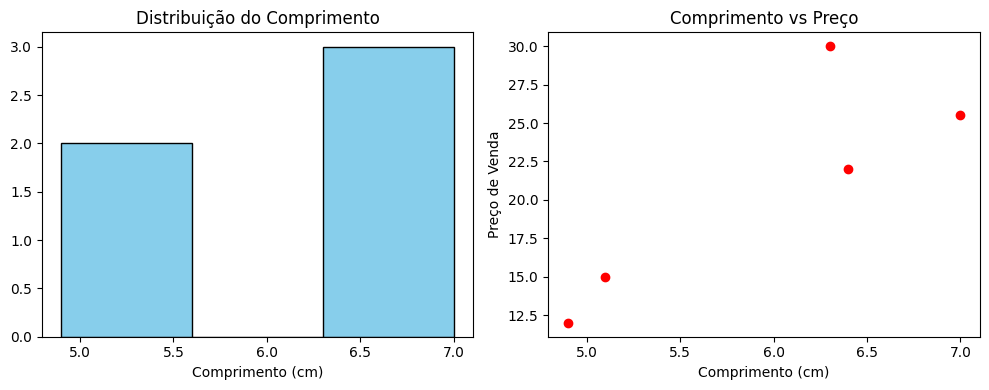

In [5]:
### Bloco de Código 5: Gráficos Básicos

# Configurando a figura
plt.figure(figsize=(10, 4))

# 1. Histograma (Distribuição de Dados)
plt.subplot(1, 2, 1) # 1 linha, 2 colunas, gráfico 1
plt.hist(df['comprimento_cm'], bins=3, color='skyblue', edgecolor='black')
plt.title('Distribuição do Comprimento')
plt.xlabel('Comprimento (cm)')

# 2. Gráfico de Dispersão (Scatter Plot - Relação entre X e Y)
plt.subplot(1, 2, 2) # 1 linha, 2 colunas, gráfico 2
plt.scatter(df['comprimento_cm'], df['preco_venda'], color='red')
plt.title('Comprimento vs Preço')
plt.xlabel('Comprimento (cm)')
plt.ylabel('Preço de Venda')

plt.tight_layout()
plt.show()

# Extra: Um gráfico altamente profissional com Seaborn em uma linha
# Requer dados sem valores nulos para funcionar perfeitamente
# sns.jointplot(x='comprimento_cm', y='preco_venda', data=df.dropna(), kind='reg')

### Bloco Markdown 6: Cheat Sheet

# 📊 Cheat Sheet: Análise de Dados em Python

### **NumPy (Matrizes e Estatística)**
| Comando | Descrição Acadêmica |
| :--- | :--- |
| `np.array(lista)` | Converte uma lista de Python em um array multidimensional. |
| `vetor_A * vetor_B` | Multiplicação elemento a elemento (*broadcasting*). |
| `matriz_A @ matriz_B` ou `.dot()` | Produto interno/multiplicação matricial. |
| `np.random.seed(int)` | Trava a semente de aletoriedade para reprodutibilidade. |
| `np.random.normal(med, std, n)` | Gera `n` números seguindo distribuição normal gaussiana. |
| `np.mean(arr)` / `np.std(arr)` | Extrai a Média e o Desvio Padrão populacional/amostral. |

### **Pandas (DataFrames e I/O)**
| Comando | Descrição Acadêmica |
| :--- | :--- |
| `pd.read_csv("arq.csv")` | Importa arquivo delimitado por vírgula em um DataFrame. |
| `df.head(n)` / `df.tail(n)` | Retorna as *n* primeiras ou *n* últimas observações da tabela. |
| `df.shape` | Retorna uma tupla contendo a dimensionalidade `(linhas, colunas)`. |
| `df.info()` | Retorna os metadados da tabela, contagem não-nula e Tipos Primitivos. |
| `df.describe()` | Gera sumarização descritiva (Média, Min, Max, Quartis 25, 50, 75). |
| `df.isna().sum()` | Retorna o total absoluto de dados nulos/faltantes no vetor. |
| `df.dropna()` | Elimina as observações que possuam dados nulos. |

### **Pandas (Filtros e Estruturação)**
| Comando | Descrição Acadêmica |
| :--- | :--- |
| `df.iloc[linha, coluna]` | Extrai amostras baseadas no número do **índice inteiro** das linhas/colunas. |
| `df.loc[linha, 'nome_col']` | Extrai amostras com base na **nomenclatura (label)** da linha/coluna. |
| `df[ df['coluna'] > X ]` | Retorna um sub-conjunto que satisfaça a condição booleana imposta. |
| `df.groupby('coluna').mean()` | Agrupa instâncias por categorias idênticas e aplica cálculo de média. |

### **Matplotlib (Visualização)**
| Comando | Descrição Acadêmica |
| :--- | :--- |
| `plt.subplots(figsize=(x,y))` | Prepara e dimensiona o espaço da figura de exibição. |
| `plt.hist(dados, bins=x)` | Gera um Histograma, partindo os dados em `x` intervalos de frequência. |
| `plt.plot(X, y)` | Gráfico de Linha. Ideal para representação de séries temporais. |
| `plt.scatter(X, y)` | Gráfico de Dispersão. Exibe a correlação pontual de variáveis X contra Y. |
| `plt.show()` | Comando final de fechamento que força a exibição do gráfico na tela. |